# 🔍 Anomaly Detection — Notebook 2/2
## Time Series, Multivariate TS, Deep Learning & Autoencoders
### Data Engineering · 4.5 h Lecture Series

---

**Estimated time:** ~2 h | **Audience:** Last-year Data Engineering students
**Prerequisites:** Notebook 1, PyTorch basics

---
## Table of Contents
1. [Time Series Anomaly Detection Overview](#1)
2. [Moving Statistics & STL Decomposition](#2)
3. [ARIMA Residuals](#3)
4. [Matrix Profile & DAMP Algorithm](#4)
5. [Multivariate TS — PCA SPE / T²](#5)
6. [Dense Autoencoder](#6)
7. [Variational Autoencoder (VAE)](#7)
8. [LSTM Autoencoder](#8)
9. [Transformer Autoencoder](#9)
10. [Ensemble & Root Cause Localisation](#10)
11. [Exercises](#11)

In [1]:
# Run once in Colab
!pip install -q scikit-learn numpy pandas matplotlib seaborn scipy torch stumpy statsmodels

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score, average_precision_score

import stumpy
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.arima.model import ARIMA

np.random.seed(42)
torch.manual_seed(42)

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
COLORS = {"normal": "#4C72B0", "anomaly": "#DD4444", "boundary": "#22AA77", "recon": "#EE9900"}
print("All imports OK — PyTorch:", torch.__version__)

All imports OK — PyTorch: 2.11.0


---
<a id='1'></a>
## 1. Time Series Anomaly Detection — Overview

### Why is time series anomaly detection different?
1. **Temporal dependency:** $x_t$ is not independent of $x_{t-1}, x_{t-2}, \ldots$
2. **Seasonality & trend:** natural periodic patterns must be separated from anomalies.
3. **Concept drift:** the definition of "normal" can shift gradually.
4. **Latency:** real-time detection vs. batch post-processing.

### Main approaches

| Approach | Idea | Examples |
|---|---|---|
| **Prediction-based** | Anomaly = large prediction error | ARIMA, LSTM, Transformer |
| **Decomposition** | Remove trend/seasonality; flag residuals | STL + IQR |
| **Similarity/shape** | Anomalous subsequences | Matrix Profile, DAMP |
| **Reconstruction** | Anomaly = high reconstruction error | Autoencoder, VAE |
| **Density** | Apply Notebook 1 methods per window | Sliding LOF |

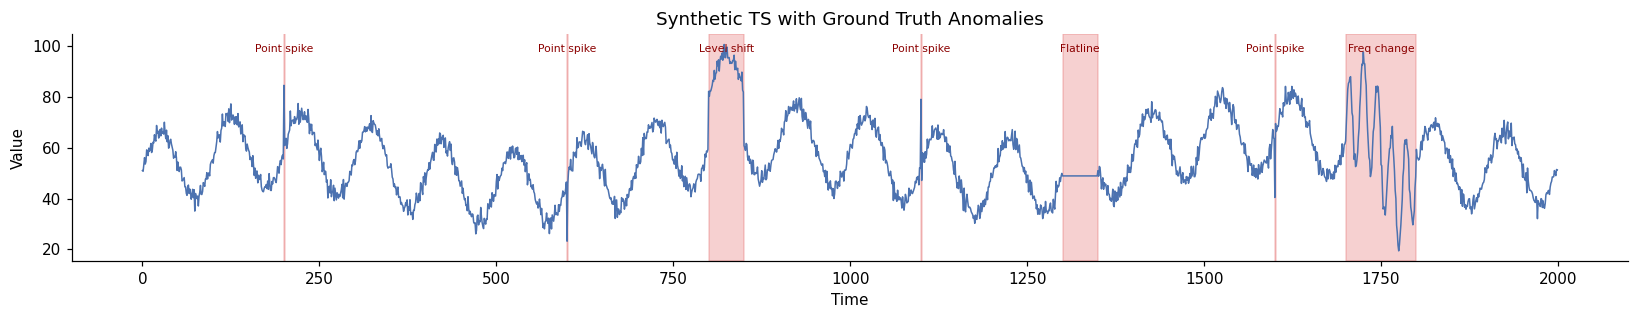

Series: 2000 pts | Anomalous: 204 (10.2%)


In [3]:
# Synthetic time series with multiple anomaly types
def generate_ts(n=2000, seed=42):
    np.random.seed(seed)
    t_ = np.arange(n)
    ts_ = (50 + 0.005 * t_
           + 15 * np.sin(2 * np.pi * t_ / 100)
           + 8  * np.sin(2 * np.pi * t_ / 700)
           + np.random.normal(0, 2, n))
    labels_ = np.zeros(n, dtype=int)
    info_ = []
    for idx in [200, 600, 1100, 1600]:
        ts_[idx] += 25 * np.random.choice([-1, 1])
        labels_[idx] = 1
        info_.append((idx, idx + 1, "Point spike"))
    ts_[800:850] += 20; labels_[800:850] = 1; info_.append((800, 850, "Level shift"))
    ts_[1300:1350] = ts_[1300]; labels_[1300:1350] = 1; info_.append((1300, 1350, "Flatline"))
    ts_[1700:1800] += 20 * np.sin(2 * np.pi * t_[1700:1800] / 20)
    labels_[1700:1800] = 1; info_.append((1700, 1800, "Freq change"))
    return t_, ts_, labels_, info_

t, ts, ts_labels, anomaly_info = generate_ts()

fig, ax = plt.subplots(figsize=(15, 3))
ax.plot(t, ts, color=COLORS["normal"], lw=1)
for s, e, lbl in anomaly_info:
    ax.axvspan(s, e, alpha=0.25, color=COLORS["anomaly"])
    ax.text((s + e) / 2, ts.max() * 0.97, lbl, fontsize=7, ha="center", color="darkred")
ax.set_xlabel("Time"); ax.set_ylabel("Value")
ax.set_title("Synthetic TS with Ground Truth Anomalies")
plt.tight_layout(); plt.show()
print(f"Series: {len(ts)} pts | Anomalous: {ts_labels.sum()} ({100*ts_labels.mean():.1f}%)")

---
<a id='2'></a>
## 2. Moving Statistics & STL Decomposition

### Moving Z-Score (sliding window)
$$\text{score}(t) = \left|\frac{x_t - \mu_{[t-w,\,t-1]}}{\sigma_{[t-w,\,t-1]}}\right|$$

**Problem:** misses slow drift and pattern changes.

### STL Decomposition (Cleveland et al., 1990)
$$x_t = T_t + S_t + R_t \quad (\text{trend + seasonal + residual})$$

**Strategy:** flag anomalies in the residual $R_t$ — it is much more stationary.

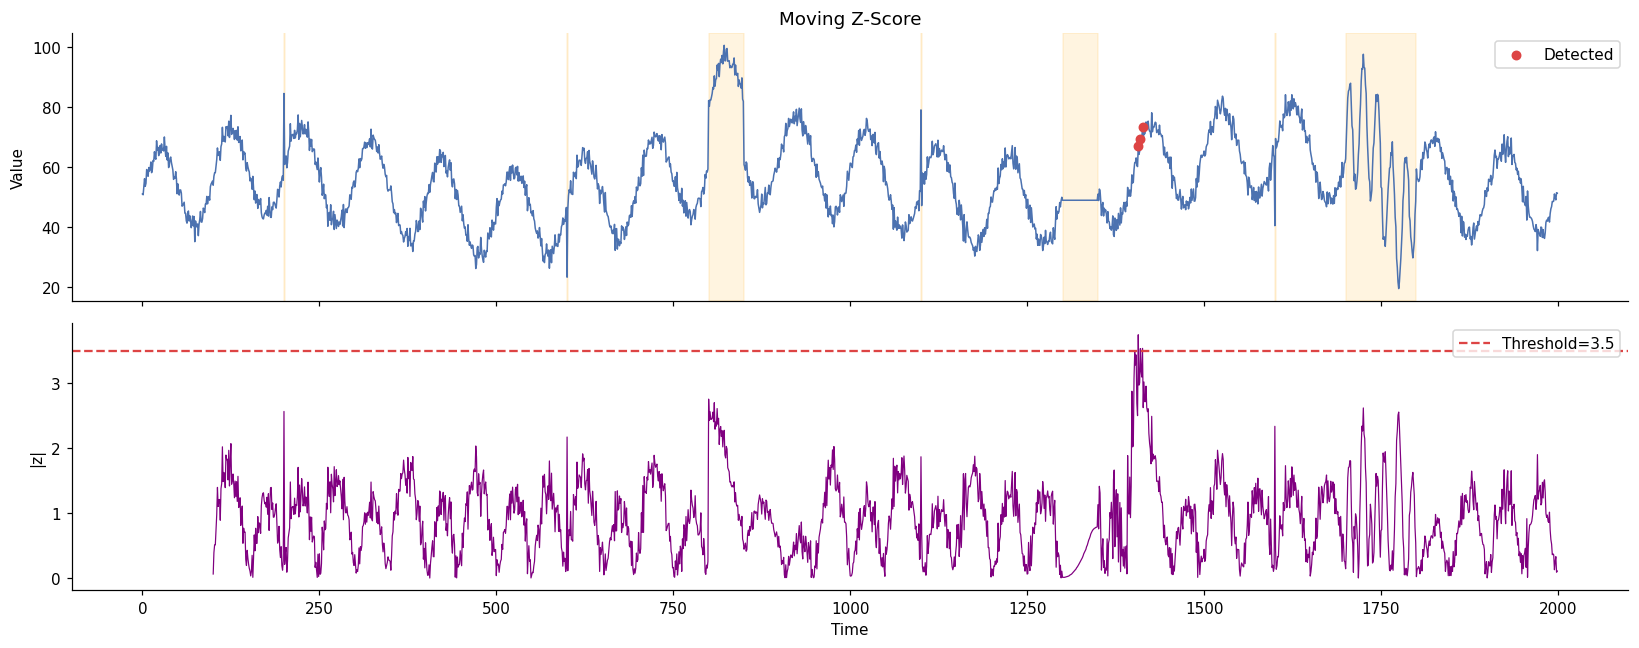

Moving Z-Score | AUROC: 0.543


In [4]:
# Moving Z-Score
def moving_zscore(ts, window=100):
    scores = np.full(len(ts), np.nan)
    for i in range(window, len(ts)):
        w = ts[i - window:i]
        scores[i] = abs(ts[i] - w.mean()) / (w.std() + 1e-10)
    return scores

mz = moving_zscore(ts, 100)
mz_pred = (mz > 3.5).astype(int)
mz_pred[:100] = 0

fig, axes = plt.subplots(2, 1, figsize=(15, 6), sharex=True)
axes[0].plot(t, ts, color=COLORS["normal"], lw=1)
axes[0].scatter(t[mz_pred == 1], ts[mz_pred == 1], color=COLORS["anomaly"], s=30, zorder=5, label="Detected")
for s, e, _ in anomaly_info:
    axes[0].axvspan(s, e, alpha=0.12, color="orange")
axes[0].set_ylabel("Value"); axes[0].set_title("Moving Z-Score"); axes[0].legend()
axes[1].plot(t, mz, color="purple", lw=0.8)
axes[1].axhline(3.5, color=COLORS["anomaly"], ls="--", label="Threshold=3.5")
axes[1].set_xlabel("Time"); axes[1].set_ylabel("|z|"); axes[1].legend()
plt.tight_layout(); plt.show()
valid = ~np.isnan(mz)
print(f"Moving Z-Score | AUROC: {roc_auc_score(ts_labels[valid], mz[valid]):.3f}")

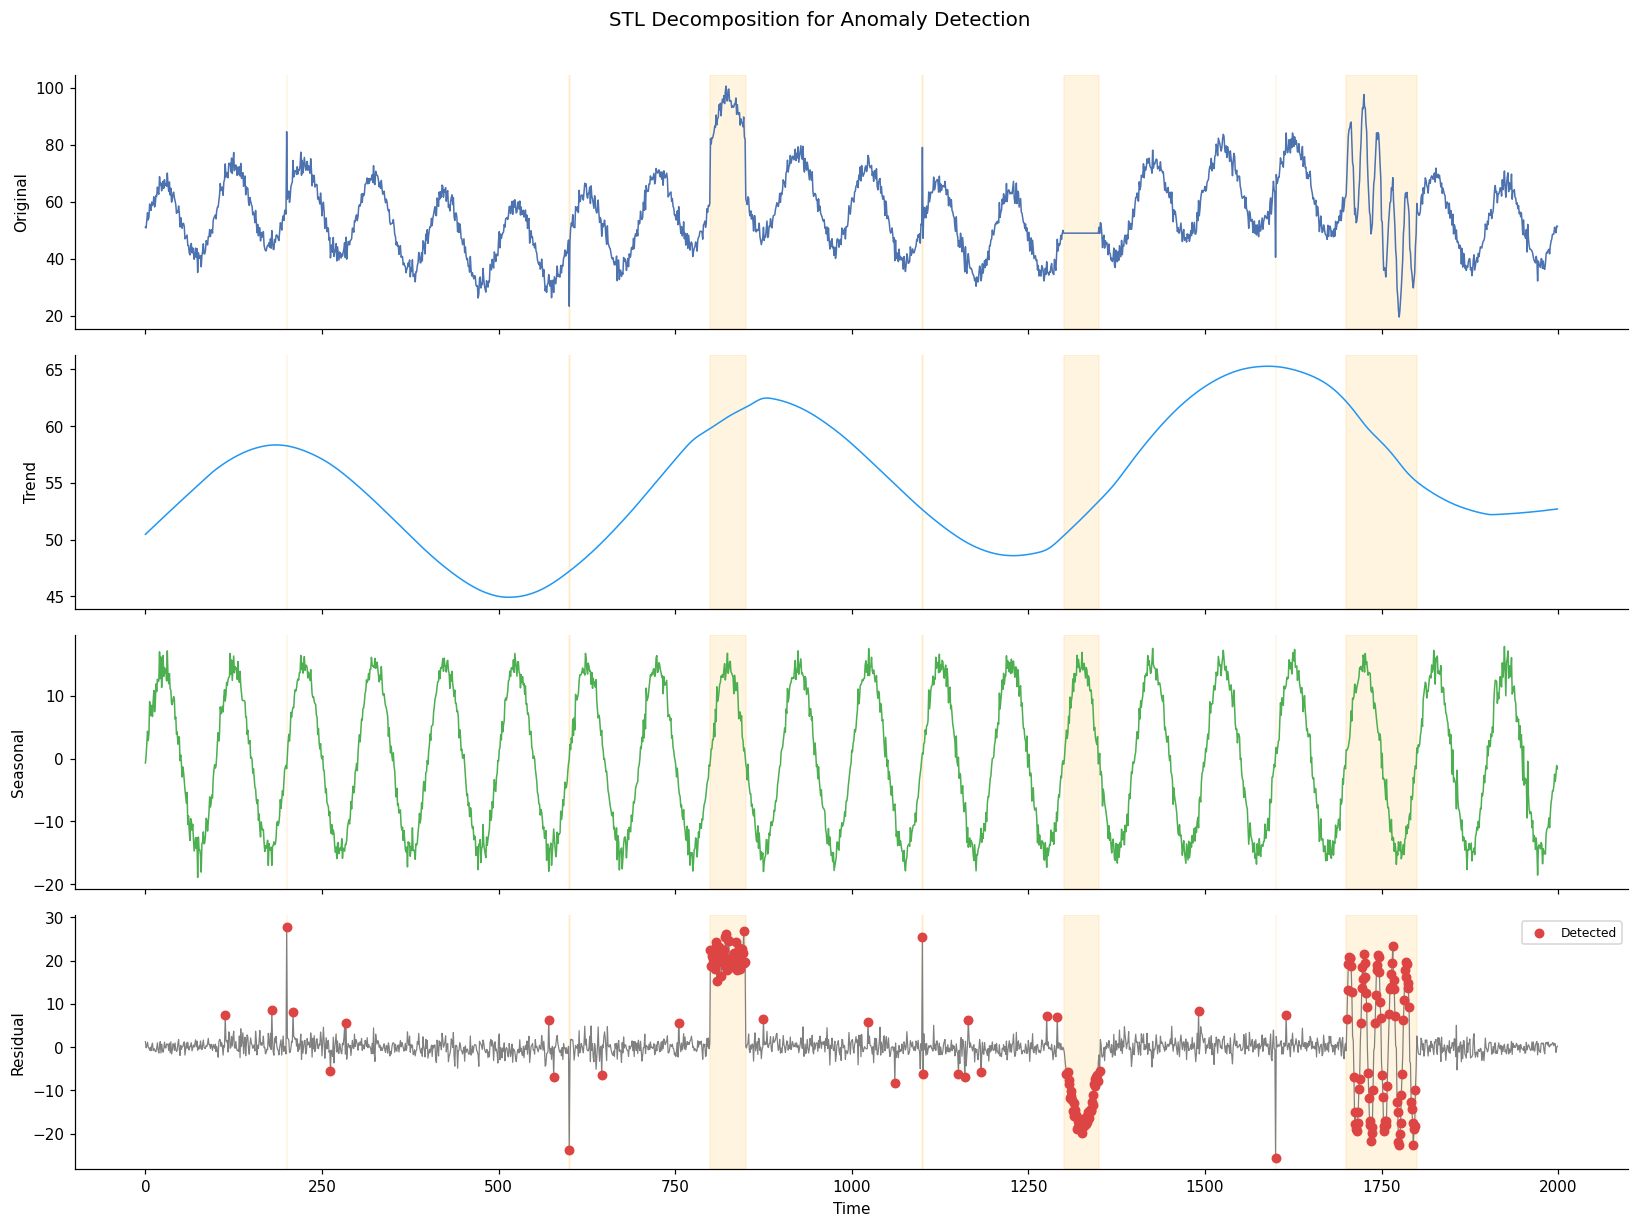

STL + ModZ | AUROC: 0.966
STL greatly improves detection by removing trend and seasonal effects first


In [5]:
# STL Decomposition
stl = STL(ts, period=100, robust=True)
res = stl.fit()
residual = res.resid

med_r = np.median(residual)
mad_r = np.median(np.abs(residual - med_r))
stl_scores = np.abs(0.6745 * (residual - med_r) / (mad_r + 1e-10))
stl_pred = (stl_scores > 3.5).astype(int)

fig, axes = plt.subplots(4, 1, figsize=(15, 11), sharex=True)
labels_plot = ["Original", "Trend", "Seasonal", "Residual"]
series_plot = [ts, res.trend, res.seasonal, residual]
colors_plot = [COLORS["normal"], "#2196F3", "#4CAF50", "gray"]
for ax, lbl, ser, col in zip(axes, labels_plot, series_plot, colors_plot):
    ax.plot(t, ser, color=col, lw=1 if lbl != "Residual" else 0.8)
    ax.set_ylabel(lbl)
    for s, e, _ in anomaly_info:
        ax.axvspan(s, e, alpha=0.12, color="orange")
axes[3].scatter(t[stl_pred == 1], residual[stl_pred == 1], color=COLORS["anomaly"], s=30, zorder=5, label="Detected")
axes[3].legend(fontsize=8); axes[3].set_xlabel("Time")
plt.suptitle("STL Decomposition for Anomaly Detection", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()
print(f"STL + ModZ | AUROC: {roc_auc_score(ts_labels, stl_scores):.3f}")
print("STL greatly improves detection by removing trend and seasonal effects first")

---
<a id='3'></a>
## 3. ARIMA Residuals

**Idea:** fit an ARIMA model; anomalies appear as large residuals.
$$x_t = c + \sum_{i=1}^p \phi_i x_{t-i} + \sum_{j=1}^q \theta_j \varepsilon_{t-j} + \varepsilon_t$$

**Anomaly score:** $s_t = |x_t - \hat{x}_t|$

Works well for linear auto-regressive processes.
**Limitation:** misses nonlinear patterns; assumes approximate stationarity.

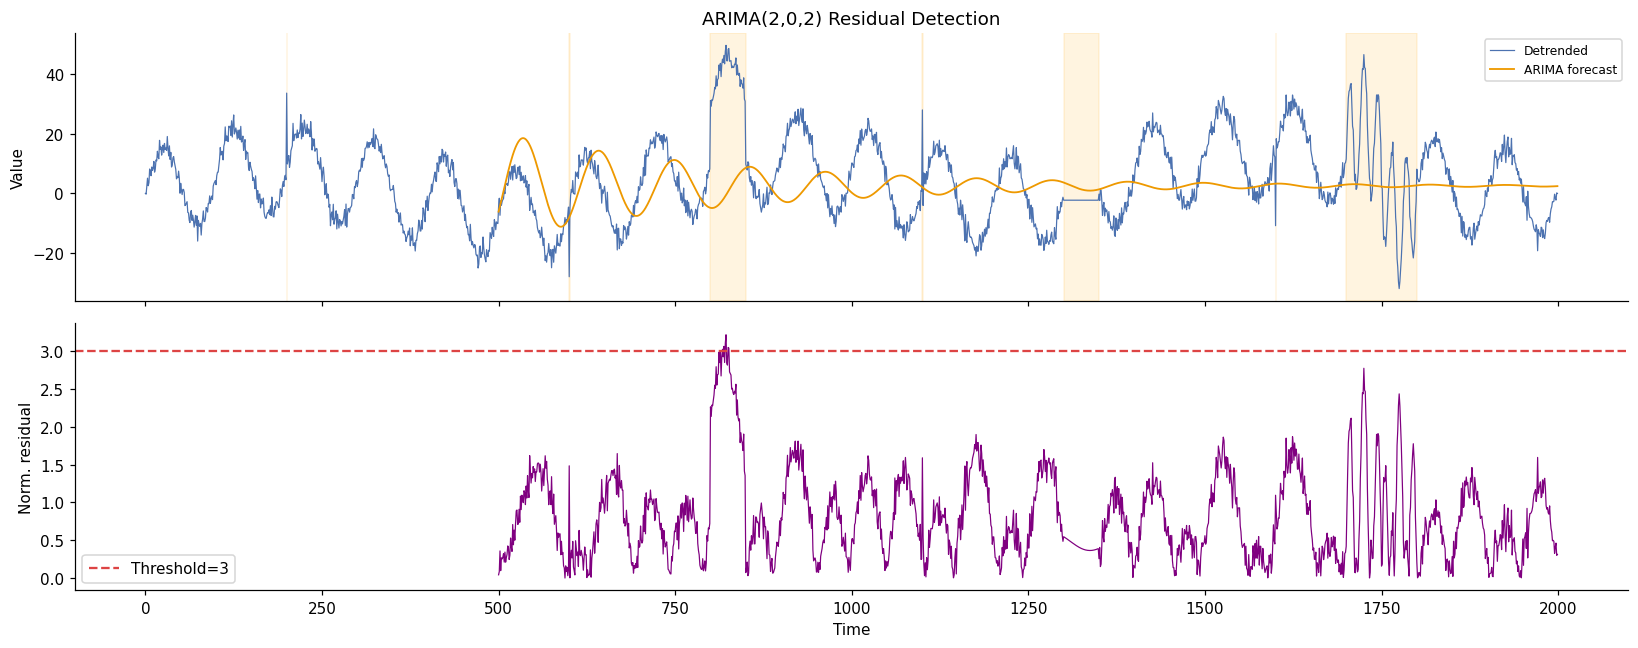

ARIMA residual | AUROC: 0.629


In [6]:
# ARIMA residuals
ts_dt = ts - np.linspace(ts[0], ts[-1], len(ts))  # detrend
train_size_arima = 500

try:
    model_arima = ARIMA(ts_dt[:train_size_arima], order=(2, 0, 2))
    fit_arima = model_arima.fit()
    forecasts = fit_arima.predict(start=train_size_arima, end=len(ts) - 1)
    resid_arima = ts_dt[train_size_arima:] - forecasts
    arima_scores = np.zeros(len(ts))
    mu_a, sig_a = resid_arima.mean(), resid_arima.std()
    arima_scores[train_size_arima:] = np.abs((resid_arima - mu_a) / (sig_a + 1e-10))

    fig, axes = plt.subplots(2, 1, figsize=(15, 6), sharex=True)
    axes[0].plot(t, ts_dt, color=COLORS["normal"], lw=0.8, label="Detrended")
    axes[0].plot(t[train_size_arima:], forecasts, color=COLORS["recon"], lw=1.2, label="ARIMA forecast")
    for s, e, _ in anomaly_info:
        axes[0].axvspan(s, e, alpha=0.12, color="orange")
    axes[0].set_ylabel("Value"); axes[0].legend(fontsize=8)
    axes[0].set_title("ARIMA(2,0,2) Residual Detection")
    axes[1].plot(t[train_size_arima:], arima_scores[train_size_arima:], color="purple", lw=0.8)
    axes[1].axhline(3, color=COLORS["anomaly"], ls="--", label="Threshold=3")
    axes[1].set_xlabel("Time"); axes[1].set_ylabel("Norm. residual"); axes[1].legend()
    plt.tight_layout(); plt.show()

    valid_a = arima_scores[train_size_arima:] != 0
    auroc_a = roc_auc_score(ts_labels[train_size_arima:][valid_a], arima_scores[train_size_arima:][valid_a])
    print(f"ARIMA residual | AUROC: {auroc_a:.3f}")
except Exception as e:
    print(f"ARIMA error: {e}")

---
<a id='4'></a>
## 4. Matrix Profile & the DAMP Algorithm

### 4.1 Matrix Profile (Yeh et al., ICDM 2016)

**Key concept:** z-normalised Euclidean distance between subsequences of length $m$.

For each position $i$, the **Matrix Profile** $P[i]$ = distance to the **nearest non-self-overlapping subsequence** (= 1-NN in subsequence space).

- $P[i] \approx 0$ → similar match exists → **normal**
- $P[i]$ large → no similar subsequence → **discord (anomaly)**

Efficient computation via STAMP/STOMP using FFT + rolling statistics.

### 4.2 DAMP — Streaming Matrix Profile (Lu et al., KDD 2022)

**Problem:** classic MP needs the full series — infeasible for streaming data.

**DAMP key ideas:**
1. **Left Matrix Profile** $MP_L[i]$ = distance to nearest neighbour *before* position $i$ (causal).
2. **PRE-CHECK:** estimate an upper bound on the left-MP using previously computed values. If the bound is below the current best discord distance → **skip expensive computation**.
3. Amortised $O(1)$ per new point in streaming mode.

**Guarantees:** no false negatives for the top-1 discord; handles billions of data points.

Computing Matrix Profile (m=100) on 2000 points...


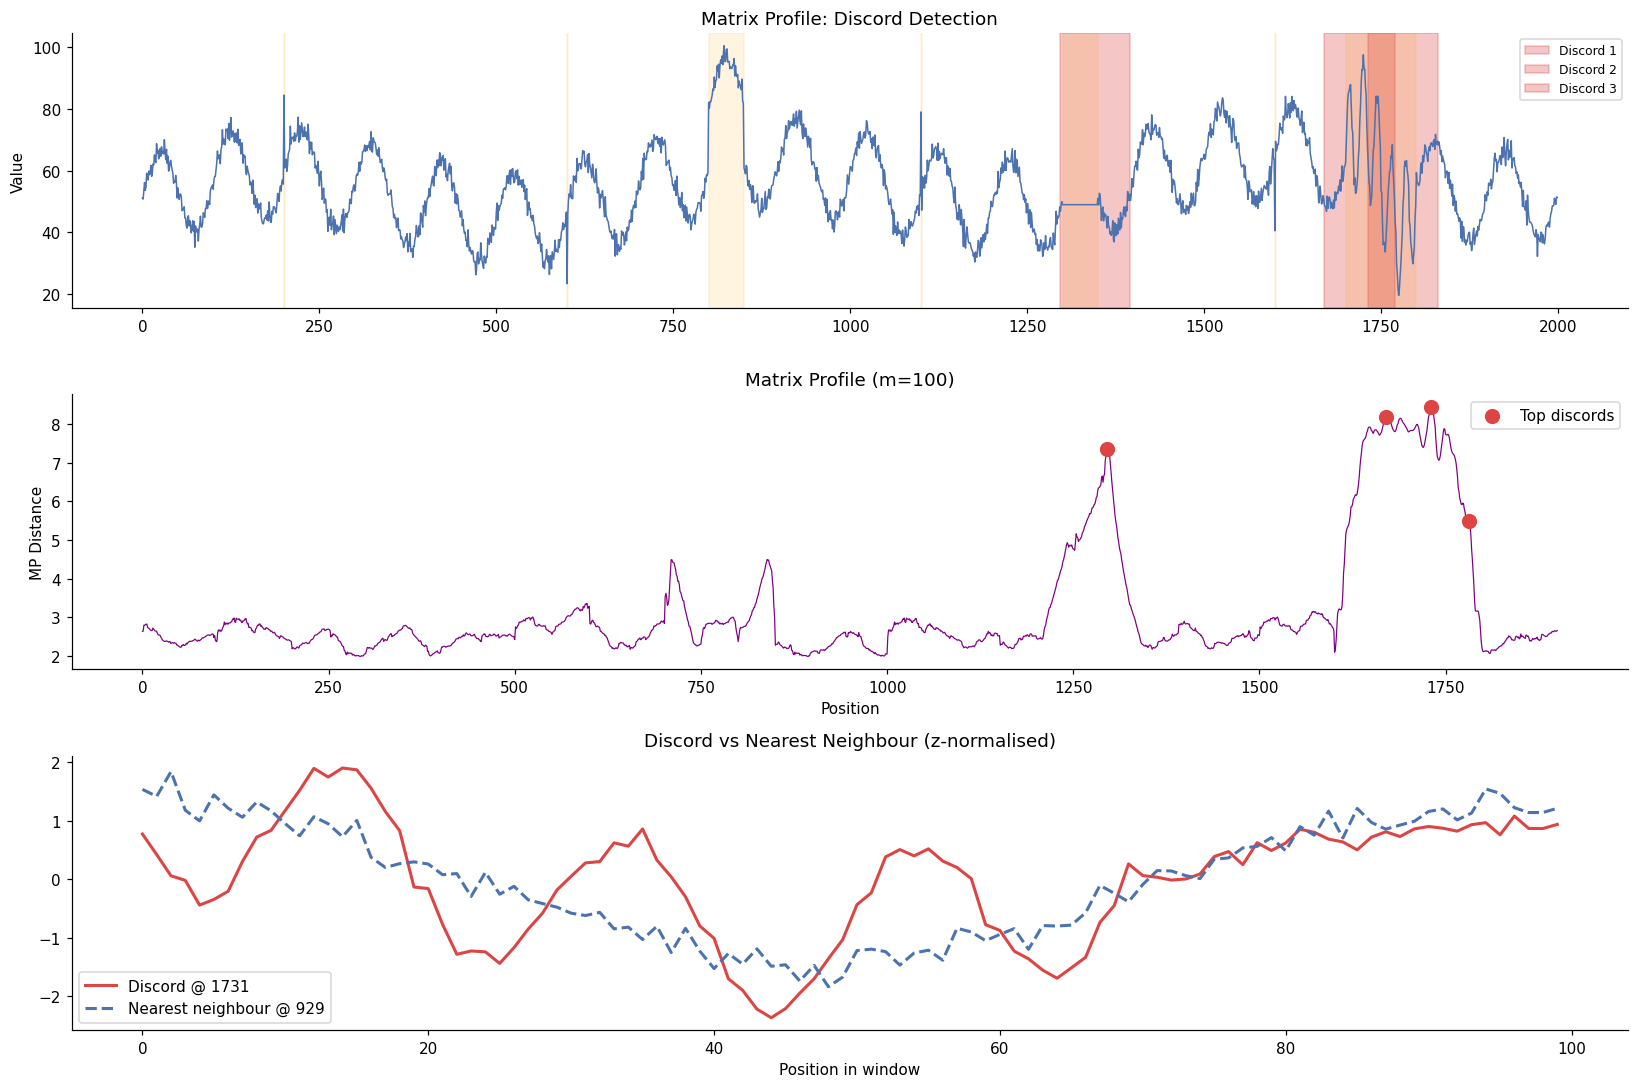

Matrix Profile | AUROC: 0.856


In [7]:
# Full Matrix Profile with STUMPY
m = 100
print(f"Computing Matrix Profile (m={m}) on {len(ts)} points...")
mp = stumpy.stump(ts.astype(np.float64), m=m)
mp_values = mp[:, 0].astype(float)

# Top discords (non-overlapping)
discord_positions = []
mp_copy = mp_values.copy()
for _ in range(4):
    idx = int(np.argmax(mp_copy))
    discord_positions.append(idx)
    lo, hi = max(0, idx - m // 2), min(len(mp_copy), idx + m // 2)
    mp_copy[lo:hi] = 0

fig, axes = plt.subplots(3, 1, figsize=(15, 10))

ax = axes[0]
ax.plot(t, ts, color=COLORS["normal"], lw=1)
for i, d in enumerate(discord_positions[:3]):
    ax.axvspan(d, d + m, alpha=0.3, color=COLORS["anomaly"], label=f"Discord {i+1}")
for s, e, _ in anomaly_info:
    ax.axvspan(s, e, alpha=0.12, color="orange")
ax.set_ylabel("Value"); ax.set_title("Matrix Profile: Discord Detection"); ax.legend(fontsize=8)

ax = axes[1]
ax.plot(mp_values, color="purple", lw=0.8)
ax.scatter(discord_positions, [mp_values[d] for d in discord_positions],
           color=COLORS["anomaly"], s=80, zorder=5, label="Top discords")
ax.set_ylabel("MP Distance"); ax.set_xlabel("Position")
ax.set_title(f"Matrix Profile (m={m})"); ax.legend()

ax = axes[2]
d0 = discord_positions[0]
nn0 = int(mp[d0, 1])
def znorm(x): return (x - x.mean()) / (x.std() + 1e-10)
ax.plot(znorm(ts[d0:d0 + m]), color=COLORS["anomaly"], lw=2, label=f"Discord @ {d0}")
ax.plot(znorm(ts[nn0:nn0 + m]), color=COLORS["normal"], lw=2, ls="--", label=f"Nearest neighbour @ {nn0}")
ax.set_title("Discord vs Nearest Neighbour (z-normalised)"); ax.set_xlabel("Position in window"); ax.legend()

plt.tight_layout(); plt.show()
mp_full = np.zeros(len(ts)); mp_full[:len(mp_values)] = mp_values
print(f"Matrix Profile | AUROC: {roc_auc_score(ts_labels, mp_full):.3f}")

All imports OK — PyTorch: 2.11.0
Computing Left MP (DAMP-simplified)...


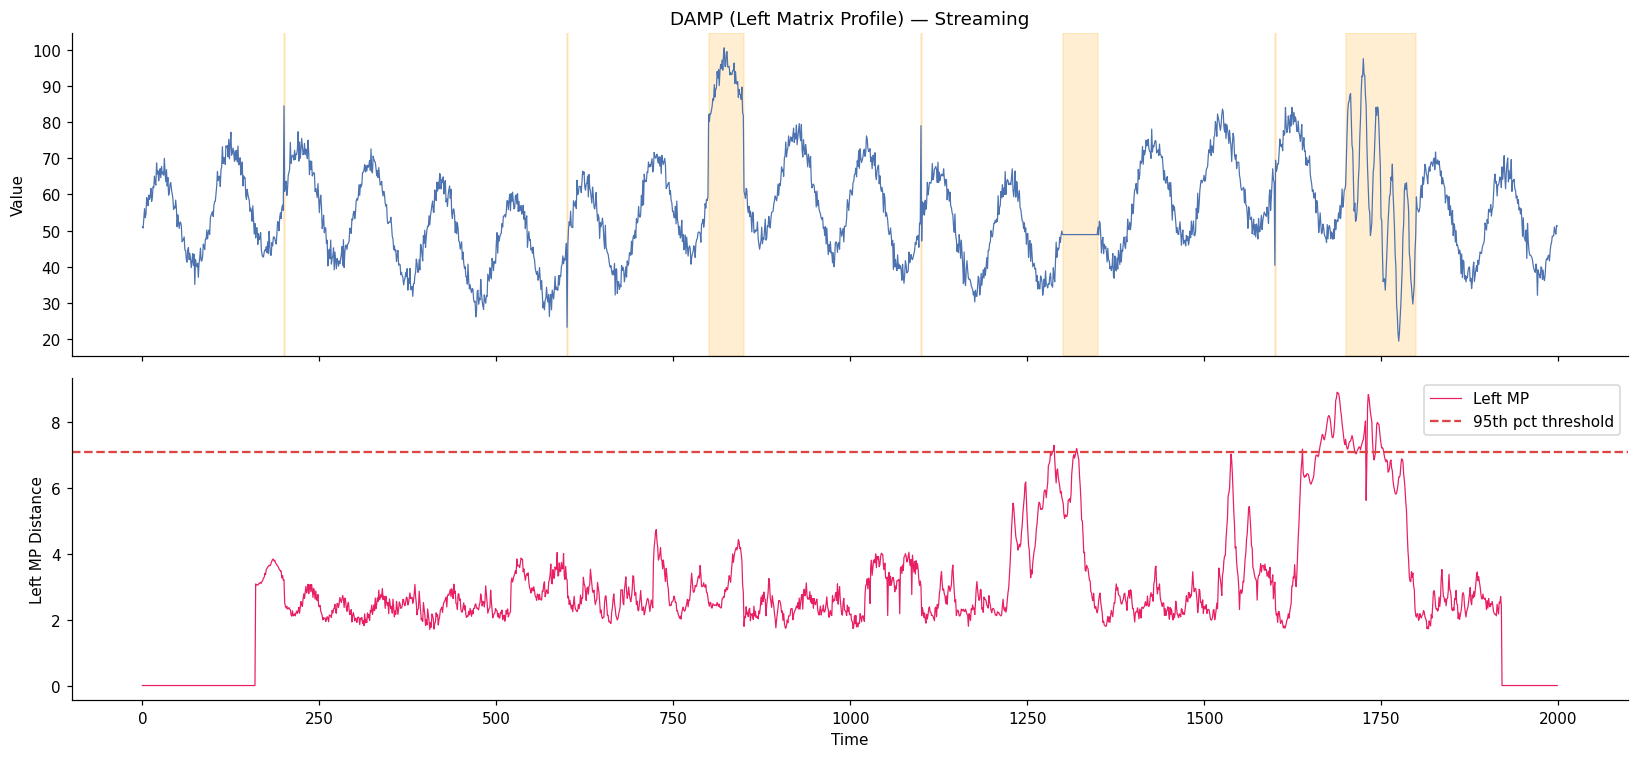

DAMP Left-MP  | AUROC: 0.829

DAMP Algorithm Summary:
 For each new point t_i:
  1. PRE-CHECK: upper-bound left MP from previous values
  2. If bound < current best discord -> SKIP (prunes ~99% of comparisons!)
  3. Otherwise: compute exact left MP distance
  4. Update running top-K discord list

 Reference: Lu et al., 'DAMP: A Dual-Stage Approximate Matrix Profile', KDD 2022


In [8]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score, average_precision_score

import stumpy
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.arima.model import ARIMA

np.random.seed(42)
torch.manual_seed(42)

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
COLORS = {"normal": "#4C72B0", "anomaly": "#DD4444", "boundary": "#22AA77", "recon": "#EE9900"}
print("All imports OK — PyTorch:", torch.__version__)

# DAMP: Left Matrix Profile (causal, streaming-friendly) — from scratch
def z_norm(x):
    s = x.std()
    return (x - x.mean()) / (s if s > 1e-10 else 1.0)

def left_matrix_profile(ts, m, n_candidates=60):
    """
    Simplified Left MP: for each position i, find the nearest past subsequence.
    This captures the core of DAMP's causal anomaly scoring.
    The full DAMP adds a pre-check to prune impossible discords early.
    """
    n = len(ts)
    lmp = np.full(n, np.inf)
    excl = m // 4
    # Ensure 'i' allows for a full subsequence of length 'm'
    for i in range(2 * m, n - m + 1):
        q = z_norm(ts[i:i + m])
        limit = max(0, i - excl)
        step  = max(1, limit // n_candidates)
        best  = np.inf
        for j in range(0, limit, step):
            # Ensure 'ts[j:j+m]' is a valid subsequence of length 'm'
            if j + m > n:
                break
            best = min(best, np.linalg.norm(q - z_norm(ts[j:j + m])))
        lmp[i] = best
    return lmp

print("Computing Left MP (DAMP-simplified)...")
lmp = left_matrix_profile(ts, m=80)
finite = np.isfinite(lmp)
lmp_c = np.where(finite, lmp, 0.0)

fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)
axes[0].plot(t, ts, color=COLORS["normal"], lw=0.8)
for s, e, _ in anomaly_info:
    axes[0].axvspan(s, e, alpha=0.18, color="orange")
axes[0].set_ylabel("Value"); axes[0].set_title("DAMP (Left Matrix Profile) — Streaming")
axes[1].plot(t, lmp_c, color="#E91E63", lw=0.8, label="Left MP")
thr_lmp = np.percentile(lmp_c[finite], 95)
axes[1].axhline(thr_lmp, color=COLORS["anomaly"], ls="--", label="95th pct threshold")
axes[1].set_xlabel("Time"); axes[1].set_ylabel("Left MP Distance"); axes[1].legend()
plt.tight_layout(); plt.show()
print(f"DAMP Left-MP  | AUROC: {roc_auc_score(ts_labels[finite], lmp_c[finite]):.3f}")
print()
print("DAMP Algorithm Summary:")
print(" For each new point t_i:")
print("  1. PRE-CHECK: upper-bound left MP from previous values")
print("  2. If bound < current best discord -> SKIP (prunes ~99% of comparisons!)")
print("  3. Otherwise: compute exact left MP distance")
print("  4. Update running top-K discord list")
print()
print(" Reference: Lu et al., 'DAMP: A Dual-Stage Approximate Matrix Profile', KDD 2022")

---
<a id='5'></a>
## 5. Multivariate Time Series — PCA SPE & Hotelling T²

With $D$ sensor channels, an anomaly may appear only in **cross-channel correlations**.

### PCA-based approach
1. Fit PCA on normal data, keep top $k$ components.
2. Reconstruct: $\hat{x} = V_k V_k^T (x - \mu) + \mu$
3. **SPE (Squared Prediction Error):** $\|x - \hat{x}\|^2$ — measures how much is unexplained.
4. **Hotelling T²:** $T^2 = \sum_{j=1}^k z_j^2 / \lambda_j$ — measures deviation in principal subspace.

Both follow approximate $\chi^2$ distributions under normality → principled thresholds.

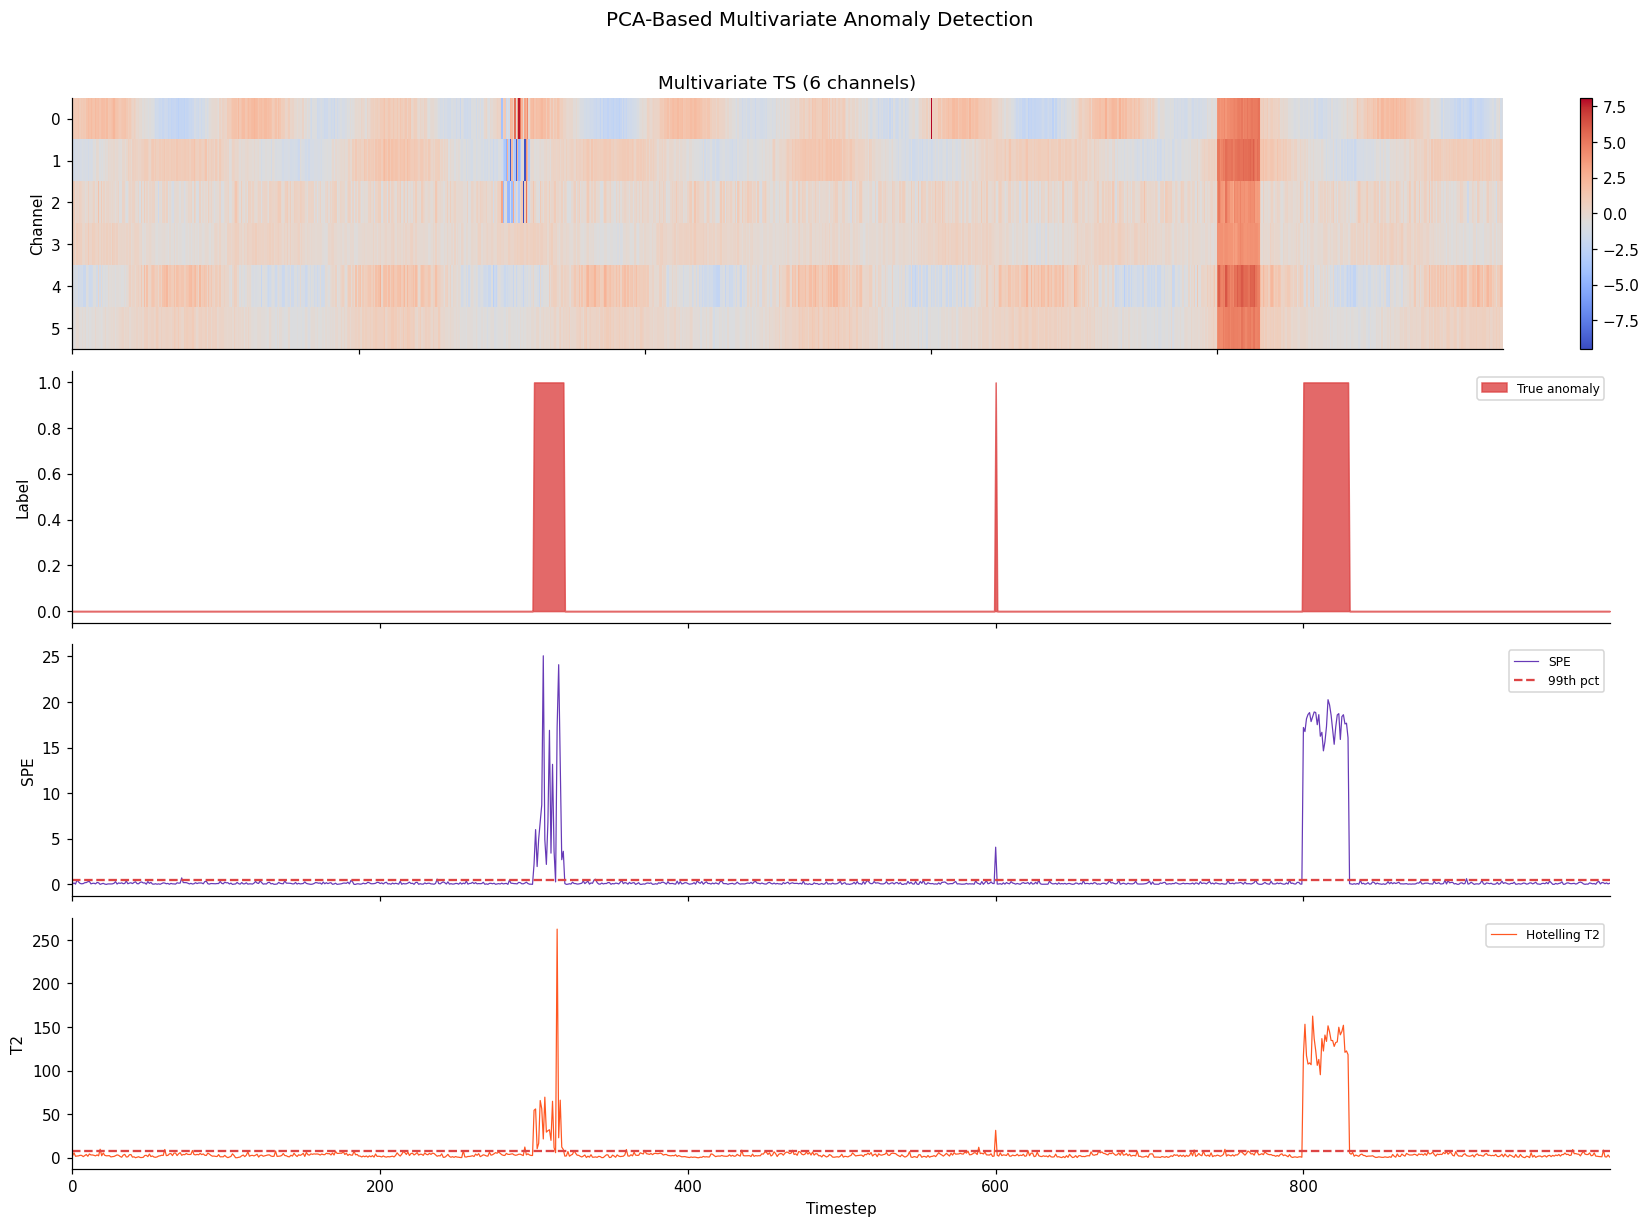

PCA SPE | AUROC: 0.998
PCA T2  | AUROC: 0.998


In [9]:
# Generate multivariate TS
def gen_mvts(n=1000, d=6, seed=0):
    np.random.seed(seed)
    t_ = np.arange(n)
    f1 = np.sin(2 * np.pi * t_ / 100) + np.random.randn(n) * 0.1
    f2 = np.cos(2 * np.pi * t_ / 150) + np.random.randn(n) * 0.1
    f3 = np.random.randn(n) * 0.3
    W  = np.random.randn(d, 3)
    X  = np.stack([f1, f2, f3], axis=1) @ W.T + np.random.randn(n, d) * 0.2
    labels_ = np.zeros(n, dtype=int)
    X[300:320, :3] += np.random.randn(20, 3) * 3; labels_[300:320] = 1  # corr break
    X[600, 0] += 8; labels_[600] = 1                                      # spike
    X[800:830] += 4; labels_[800:830] = 1                                 # level shift
    return X, labels_

X_mv, y_mv = gen_mvts()
train_sz = 250
scaler_mv = StandardScaler()
X_mv_sc = scaler_mv.fit_transform(X_mv)
X_train_sc = X_mv_sc[:train_sz]

pca = PCA(n_components=3)
pca.fit(X_train_sc)
X_recon_pca = pca.inverse_transform(pca.transform(X_mv_sc))
spe_scores  = np.sum((X_mv_sc - X_recon_pca) ** 2, axis=1)
z_proj = pca.transform(X_mv_sc)
t2_scores = np.sum((z_proj / np.sqrt(pca.explained_variance_)) ** 2, axis=1)

fig, axes = plt.subplots(4, 1, figsize=(15, 11), sharex=True)
im = axes[0].imshow(X_mv.T, aspect="auto", cmap="coolwarm", interpolation="none")
plt.colorbar(im, ax=axes[0], fraction=0.02); axes[0].set_ylabel("Channel"); axes[0].set_title("Multivariate TS (6 channels)")
axes[1].fill_between(range(len(y_mv)), y_mv, alpha=0.8, color=COLORS["anomaly"], label="True anomaly")
axes[1].set_ylabel("Label"); axes[1].legend(fontsize=8)
axes[2].plot(spe_scores, color="#673AB7", lw=0.8, label="SPE")
t_spe = np.percentile(spe_scores[:train_sz], 99)
axes[2].axhline(t_spe, color=COLORS["anomaly"], ls="--", label="99th pct"); axes[2].legend(fontsize=8); axes[2].set_ylabel("SPE")
axes[3].plot(t2_scores, color="#FF5722", lw=0.8, label="Hotelling T2")
t_t2 = np.percentile(t2_scores[:train_sz], 99)
axes[3].axhline(t_t2, color=COLORS["anomaly"], ls="--"); axes[3].set_xlabel("Timestep"); axes[3].set_ylabel("T2"); axes[3].legend(fontsize=8)
plt.suptitle("PCA-Based Multivariate Anomaly Detection", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()
print(f"PCA SPE | AUROC: {roc_auc_score(y_mv, spe_scores):.3f}")
print(f"PCA T2  | AUROC: {roc_auc_score(y_mv, t2_scores):.3f}")

---
<a id='6'></a>
## 6. Dense Autoencoder

Trained **only on normal data**. Learns to reconstruct normal patterns.
Anomaly score = reconstruction error $\|x - \hat{x}\|^2$.

Architecture:
```
x → [Linear → BN → ReLU] × n → bottleneck z → [Linear → BN → ReLU] × n → x̂
```
High error → x does not fit the learned manifold of normality.

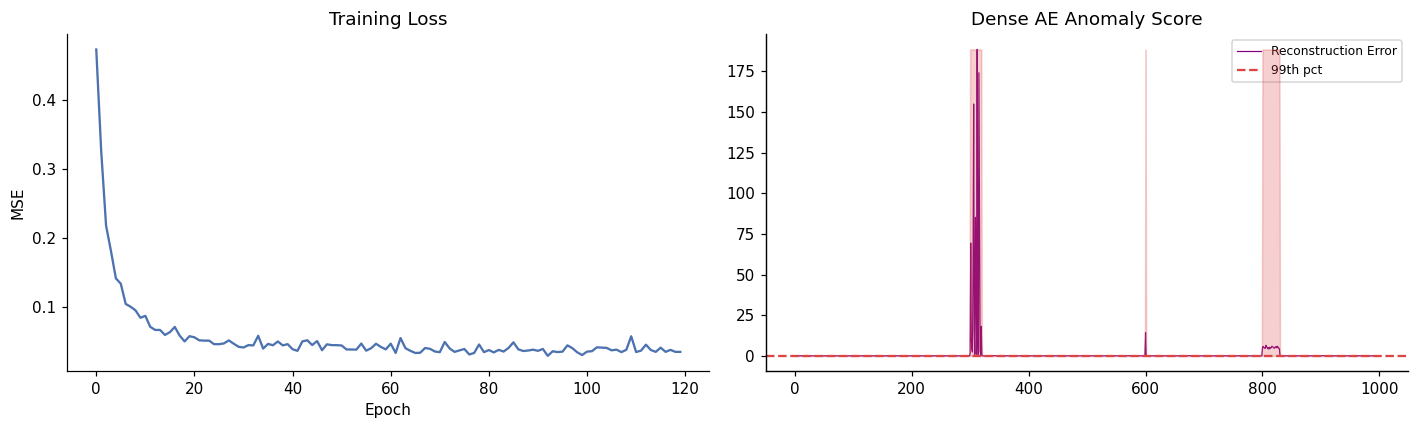

Dense AE | AUROC: 1.000


In [10]:
class DenseAE(nn.Module):
    def __init__(self, in_dim, lat=3, hidden=[32, 16]):
        super().__init__()
        enc, prev = [], in_dim
        for h in hidden:
            enc += [nn.Linear(prev, h), nn.ReLU(), nn.BatchNorm1d(h)]
            prev = h
        enc.append(nn.Linear(prev, lat))
        self.enc = nn.Sequential(*enc)
        dec, prev = [], lat
        for h in reversed(hidden):
            dec += [nn.Linear(prev, h), nn.ReLU(), nn.BatchNorm1d(h)]
            prev = h
        dec.append(nn.Linear(prev, in_dim))
        self.dec = nn.Sequential(*dec)
    def forward(self, x): return self.dec(self.enc(x))

X_tr = torch.FloatTensor(X_train_sc)
X_all_t = torch.FloatTensor(X_mv_sc)
loader = DataLoader(TensorDataset(X_tr, X_tr), batch_size=32, shuffle=True)

ae = DenseAE(6, lat=3)
opt = optim.Adam(ae.parameters(), lr=1e-3)
losses_ae = []
for ep in range(120):
    ae.train(); ep_l = 0
    for xb, _ in loader:
        opt.zero_grad()
        loss = nn.functional.mse_loss(ae(xb), xb)
        loss.backward(); opt.step(); ep_l += loss.item()
    losses_ae.append(ep_l / len(loader))

ae.eval()
with torch.no_grad():
    ae_scores = torch.mean((X_all_t - ae(X_all_t)) ** 2, dim=1).numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(losses_ae, color=COLORS["normal"]); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE"); axes[0].set_title("Training Loss")
axes[1].plot(ae_scores, color="purple", lw=0.8, label="Reconstruction Error")
axes[1].axhline(np.percentile(ae_scores[:train_sz], 99), color=COLORS["anomaly"], ls="--", label="99th pct")
ax2 = axes[1].twinx(); ax2.fill_between(range(len(y_mv)), y_mv, alpha=0.25, color=COLORS["anomaly"]); ax2.set_yticks([])
axes[1].set_title("Dense AE Anomaly Score"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f"Dense AE | AUROC: {roc_auc_score(y_mv, ae_scores):.3f}")

---
<a id='7'></a>
## 7. Variational Autoencoder (VAE)

VAE (Kingma & Welling, 2014) imposes a probabilistic structure on the latent space.

- Encoder: $q(z|x) = \mathcal{N}(\mu_z, \sigma_z^2)$
- Decoder: $p(x|z)$

**ELBO loss:**
$$\mathcal{L} = \underbrace{\mathbb{E}[\|x-\hat{x}\|^2]}_{\text{reconstruction}} + \underbrace{D_{KL}(q(z|x)\|p(z))}_{\text{regularisation}}$$

**Anomaly score:** Monte Carlo estimate of $\mathbb{E}_z[\|x - f_{dec}(z)\|^2]$ — averaged over multiple samples from $q(z|x)$.

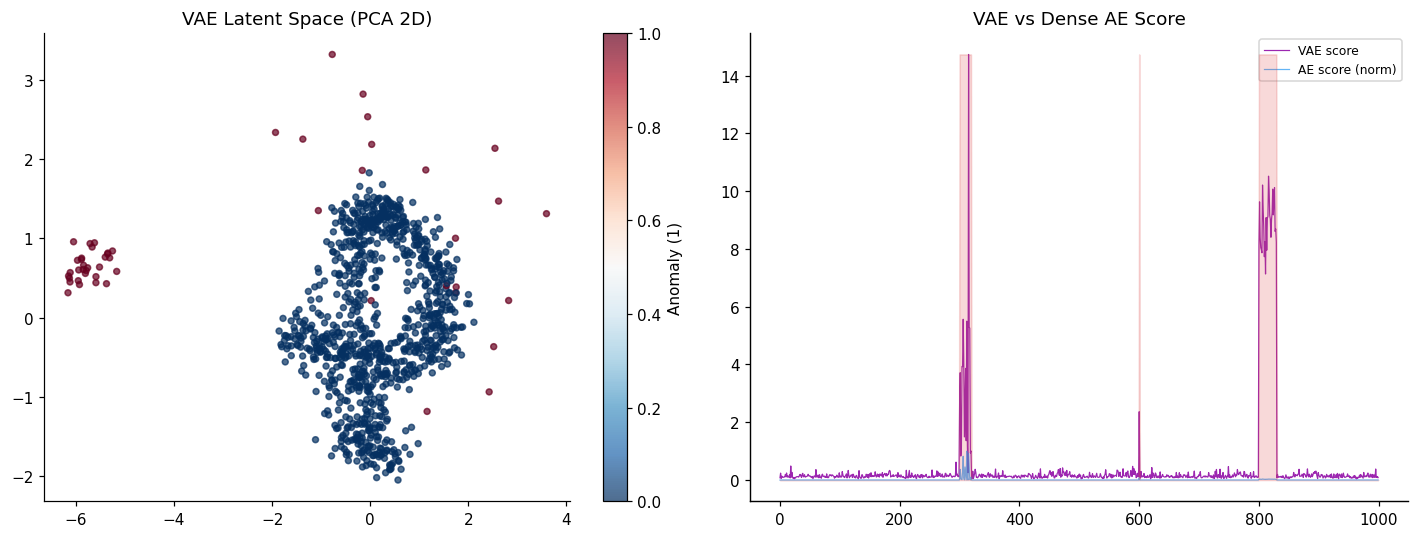

VAE      | AUROC: 0.998
Dense AE | AUROC: 1.000


In [11]:
class VAE(nn.Module):
    def __init__(self, in_dim, lat=3, h=32):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(in_dim, h), nn.ReLU(), nn.Linear(h, h), nn.ReLU())
        self.fc_mu  = nn.Linear(h, lat)
        self.fc_lv  = nn.Linear(h, lat)
        self.dec = nn.Sequential(nn.Linear(lat, h), nn.ReLU(), nn.Linear(h, h), nn.ReLU(), nn.Linear(h, in_dim))
    def encode(self, x):
        h = self.enc(x); return self.fc_mu(h), self.fc_lv(h)
    def reparameterise(self, mu, lv):
        return mu + torch.exp(0.5 * lv) * torch.randn_like(mu)
    def forward(self, x):
        mu, lv = self.encode(x); return self.dec(self.reparameterise(mu, lv)), mu, lv
    def elbo(self, x, xh, mu, lv, beta=0.5):
        rec = nn.functional.mse_loss(xh, x, reduction="sum")
        kld = -0.5 * torch.sum(1 + lv - mu ** 2 - lv.exp())
        return (rec + beta * kld) / x.size(0)
    def score(self, x, K=20):
        mu, lv = self.encode(x)
        sc = [torch.mean((x - self.dec(self.reparameterise(mu, lv))) ** 2, dim=1) for _ in range(K)]
        return torch.stack(sc).mean(0)

vae = VAE(6, lat=3)
opt_v = optim.Adam(vae.parameters(), lr=1e-3)
for ep in range(120):
    vae.train()
    for xb, _ in loader:
        opt_v.zero_grad()
        xh, mu, lv = vae(xb)
        vae.elbo(xb, xh, mu, lv).backward()
        opt_v.step()

vae.eval()
with torch.no_grad():
    vae_scores = vae.score(X_all_t).numpy()
    mu_all, _ = vae.encode(X_all_t)
    z2d = PCA(n_components=2).fit_transform(mu_all.numpy())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sc = axes[0].scatter(*z2d.T, c=y_mv, cmap="RdBu_r", s=15, alpha=0.7)
plt.colorbar(sc, ax=axes[0], label="Anomaly (1)"); axes[0].set_title("VAE Latent Space (PCA 2D)")
axes[1].plot(vae_scores, color="#9C27B0", lw=0.8, label="VAE score")
axes[1].plot(ae_scores / ae_scores.max(), color="#2196F3", lw=0.8, alpha=0.7, label="AE score (norm)")
ax2 = axes[1].twinx(); ax2.fill_between(range(len(y_mv)), y_mv, alpha=0.2, color=COLORS["anomaly"]); ax2.set_yticks([])
axes[1].set_title("VAE vs Dense AE Score"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f"VAE      | AUROC: {roc_auc_score(y_mv, vae_scores):.3f}")
print(f"Dense AE | AUROC: {roc_auc_score(y_mv, ae_scores):.3f}")

---
<a id='8'></a>
## 8. LSTM Autoencoder

For sequential data, LSTM autoencoders model temporal dependencies.

| | Dense AE | LSTM AE |
|---|---|---|
| Temporal ordering | ignored | modelled |
| Pattern recognition | local features | temporal patterns |
| Training speed | fast | slower |

**Architecture:**
```
[x_1..x_W] → Encoder LSTM → bottleneck z → Decoder LSTM → [x̂_1..x̂_W]
```

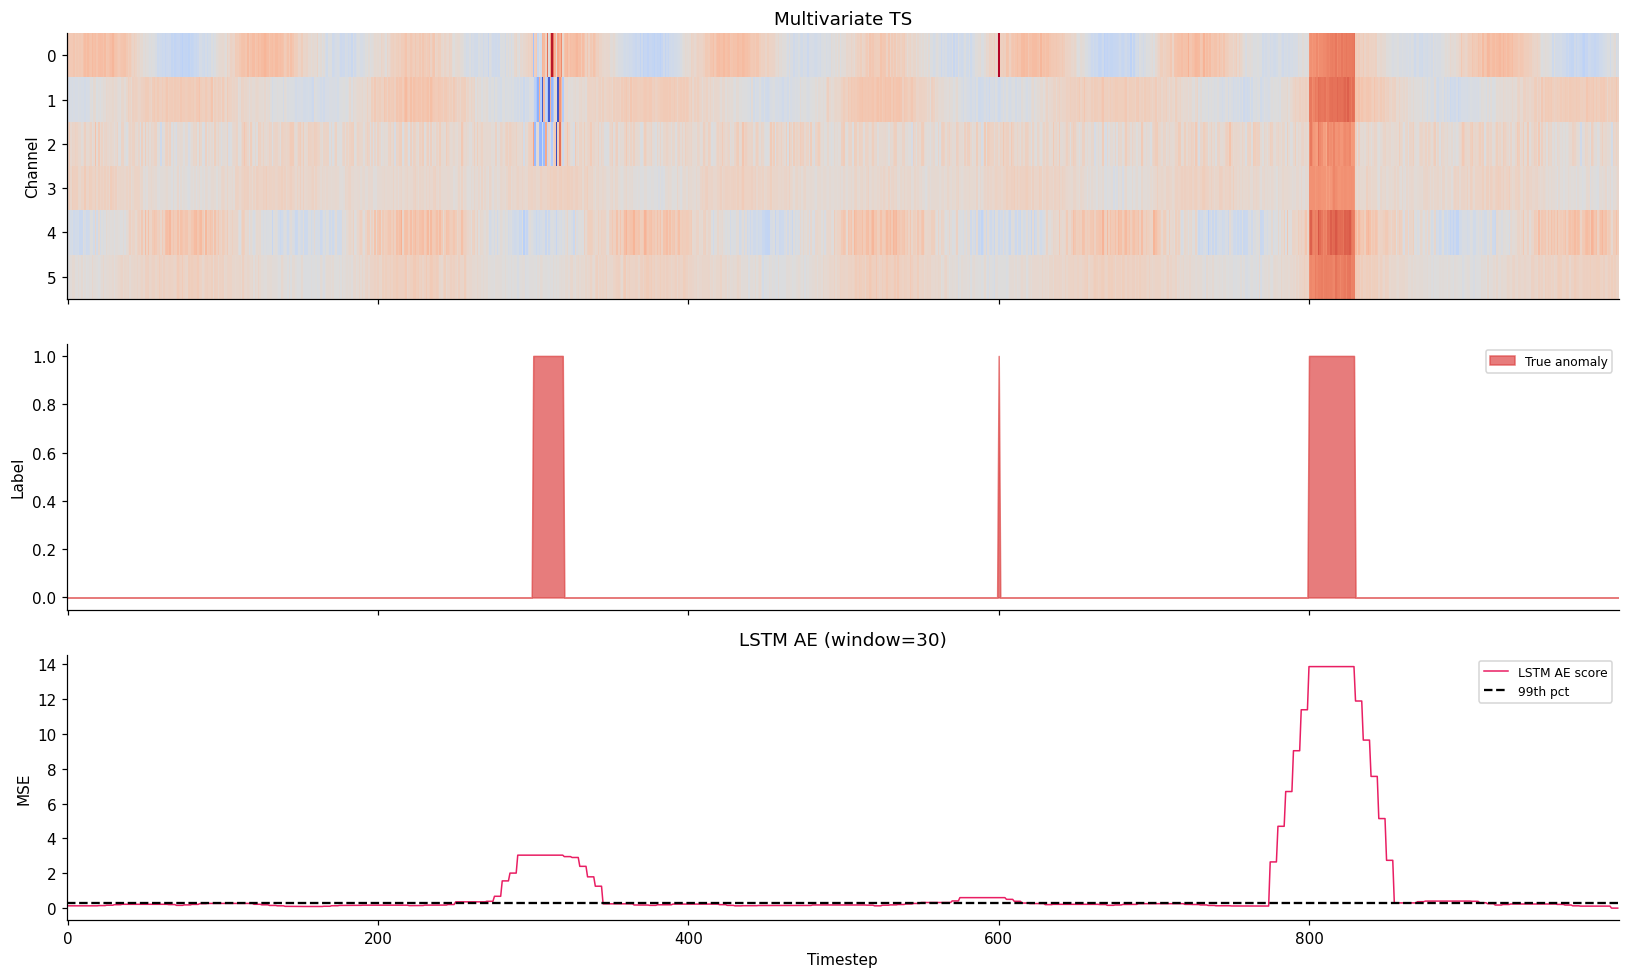

LSTM AE  | AUROC: 0.979


In [12]:
class LSTMAe(nn.Module):
    def __init__(self, in_dim, hid=32, lat=8):
        super().__init__()
        self.enc = nn.LSTM(in_dim, hid, batch_first=True)
        self.bot = nn.Linear(hid, lat)
        self.exp = nn.Linear(lat, hid)
        self.dec = nn.LSTM(hid, hid, batch_first=True)
        self.out = nn.Linear(hid, in_dim)
    def forward(self, x):
        _, (h, _) = self.enc(x)
        z = self.bot(h[-1])
        zr = self.exp(z).unsqueeze(1).repeat(1, x.size(1), 1)
        do, _ = self.dec(zr)
        return self.out(do)

def make_windows(data, W, step=5):
    wins, idxs = [], []
    for i in range(0, len(data) - W, step):
        wins.append(data[i:i + W]); idxs.append(i)
    return np.array(wins), np.array(idxs)

W = 30
wins, win_idx = make_windows(X_mv_sc, W)
train_mask = win_idx < train_sz
X_wtr = torch.FloatTensor(wins[train_mask])
X_wall = torch.FloatTensor(wins)
ld = DataLoader(TensorDataset(X_wtr, X_wtr), batch_size=32, shuffle=True)

lstm_ae = LSTMAe(6, hid=32, lat=8)
opt_l = optim.Adam(lstm_ae.parameters(), lr=1e-3)
for ep in range(80):
    lstm_ae.train()
    for xb, _ in ld:
        opt_l.zero_grad()
        loss = nn.functional.mse_loss(lstm_ae(xb), xb)
        loss.backward(); nn.utils.clip_grad_norm_(lstm_ae.parameters(), 1.0); opt_l.step()

lstm_ae.eval()
with torch.no_grad():
    ws = torch.mean((X_wall - lstm_ae(X_wall)) ** 2, dim=(1, 2)).numpy()
ts_lstm = np.zeros(len(X_mv))
for i, idx in enumerate(win_idx):
    ts_lstm[idx:idx + W] = np.maximum(ts_lstm[idx:idx + W], ws[i])

fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=True)
axes[0].imshow(X_mv.T, aspect="auto", cmap="coolwarm", interpolation="none"); axes[0].set_ylabel("Channel"); axes[0].set_title("Multivariate TS")
axes[1].fill_between(range(len(y_mv)), y_mv, color=COLORS["anomaly"], alpha=0.7, label="True anomaly"); axes[1].set_ylabel("Label"); axes[1].legend(fontsize=8)
axes[2].plot(ts_lstm, color="#E91E63", lw=1, label="LSTM AE score")
axes[2].axhline(np.percentile(ts_lstm[:train_sz], 99), color="black", ls="--", label="99th pct")
axes[2].set_xlabel("Timestep"); axes[2].set_ylabel("MSE"); axes[2].set_title(f"LSTM AE (window={W})"); axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f"LSTM AE  | AUROC: {roc_auc_score(y_mv, ts_lstm):.3f}")

---
<a id='9'></a>
## 9. Transformer Autoencoder

Transformers model **long-range dependencies** via self-attention across time steps.

### Anomaly Transformer insight (Xu et al., NeurIPS 2022)
In a normal series, self-attention concentrates on **nearby timesteps** (temporal locality).
Anomalous positions cannot find similar neighbours → attention becomes **diffuse**.

Anomaly score = KL divergence between a Gaussian prior (locality bias) and the learned attention.

**Our implementation:** simpler reconstruction-based Transformer AE with positional encoding.

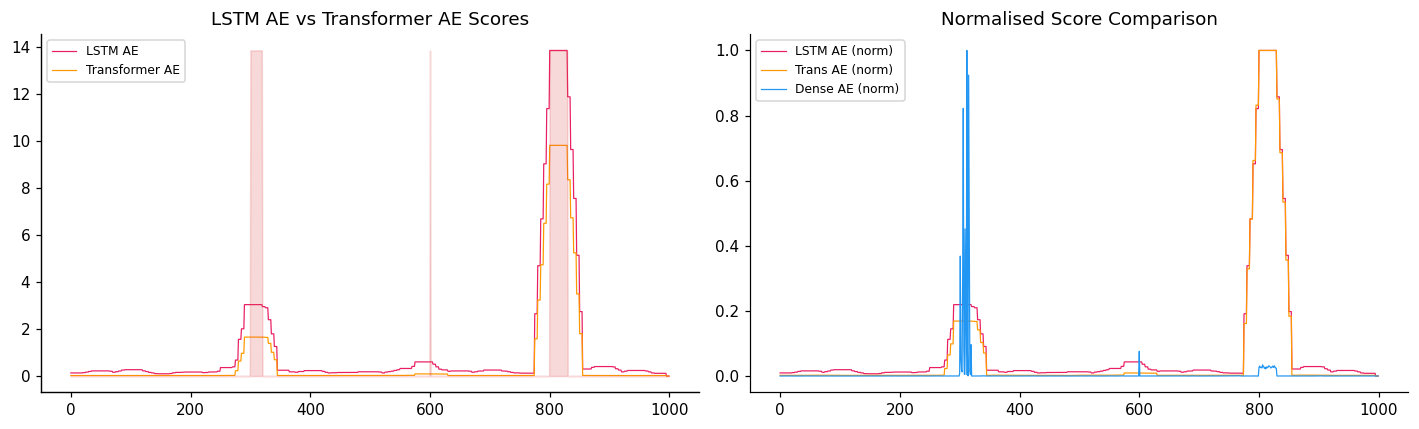

Transformer AE | AUROC: 0.977
LSTM AE        | AUROC: 0.979
Dense AE       | AUROC: 1.000


In [13]:
class PosEnc(nn.Module):
    def __init__(self, d, maxlen=500):
        super().__init__()
        pe = torch.zeros(maxlen, d)
        pos = torch.arange(maxlen).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d, 2).float() * (-np.log(10000.0) / d))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div[:d // 2])
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x): return x + self.pe[:, :x.size(1)]

class TransAE(nn.Module):
    def __init__(self, in_dim, d=32, heads=4, layers=2, ff=64):
        super().__init__()
        self.proj = nn.Linear(in_dim, d)
        self.pe   = PosEnc(d)
        el = nn.TransformerEncoderLayer(d, heads, ff, dropout=0.1, batch_first=True)
        self.tr   = nn.TransformerEncoder(el, layers)
        self.out  = nn.Linear(d, in_dim)
    def forward(self, x):
        return self.out(self.tr(self.pe(self.proj(x))))

trans_ae = TransAE(6)
opt_t = optim.Adam(trans_ae.parameters(), lr=5e-4)
for ep in range(80):
    trans_ae.train()
    for xb, _ in ld:
        opt_t.zero_grad()
        loss = nn.functional.mse_loss(trans_ae(xb), xb)
        loss.backward(); nn.utils.clip_grad_norm_(trans_ae.parameters(), 1.0); opt_t.step()

trans_ae.eval()
with torch.no_grad():
    ws_t = torch.mean((X_wall - trans_ae(X_wall)) ** 2, dim=(1, 2)).numpy()
ts_trans = np.zeros(len(X_mv))
for i, idx in enumerate(win_idx):
    ts_trans[idx:idx + W] = np.maximum(ts_trans[idx:idx + W], ws_t[i])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(ts_lstm,  color="#E91E63", lw=0.8, label="LSTM AE")
axes[0].plot(ts_trans, color="#FF9800", lw=0.8, label="Transformer AE")
ax2 = axes[0].twinx(); ax2.fill_between(range(len(y_mv)), y_mv, alpha=0.2, color=COLORS["anomaly"]); ax2.set_yticks([])
axes[0].set_title("LSTM AE vs Transformer AE Scores"); axes[0].legend(fontsize=8)
axes[1].plot(ts_lstm / (ts_lstm.max() + 1e-10),  color="#E91E63", lw=0.8, label="LSTM AE (norm)")
axes[1].plot(ts_trans / (ts_trans.max() + 1e-10), color="#FF9800", lw=0.8, label="Trans AE (norm)")
axes[1].plot(ae_scores / (ae_scores.max() + 1e-10), color="#2196F3", lw=0.8, label="Dense AE (norm)")
axes[1].set_title("Normalised Score Comparison"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f"Transformer AE | AUROC: {roc_auc_score(y_mv, ts_trans):.3f}")
print(f"LSTM AE        | AUROC: {roc_auc_score(y_mv, ts_lstm):.3f}")
print(f"Dense AE       | AUROC: {roc_auc_score(y_mv, ae_scores):.3f}")

---
<a id='10'></a>
## 10. Ensemble & Root Cause Localisation

### Score fusion pipeline
1. Normalise each score to $[0, 1]$ using training-set min-max.
2. Combine with mean (or max, or a learned meta-model).
3. Apply dynamic threshold (percentile of training scores).

### Root cause localisation
For AE-based methods, per-channel reconstruction error reveals **which channels are anomalous** — useful for alerting operators to the right sensor.

Method                  AUROC    AUPRC
PCA SPE                 0.998    0.988
Dense AE                1.000    0.998
VAE                     0.998    0.988
LSTM AE                 0.979    0.790
Transformer AE          0.977    0.781
ENSEMBLE                1.000    0.998


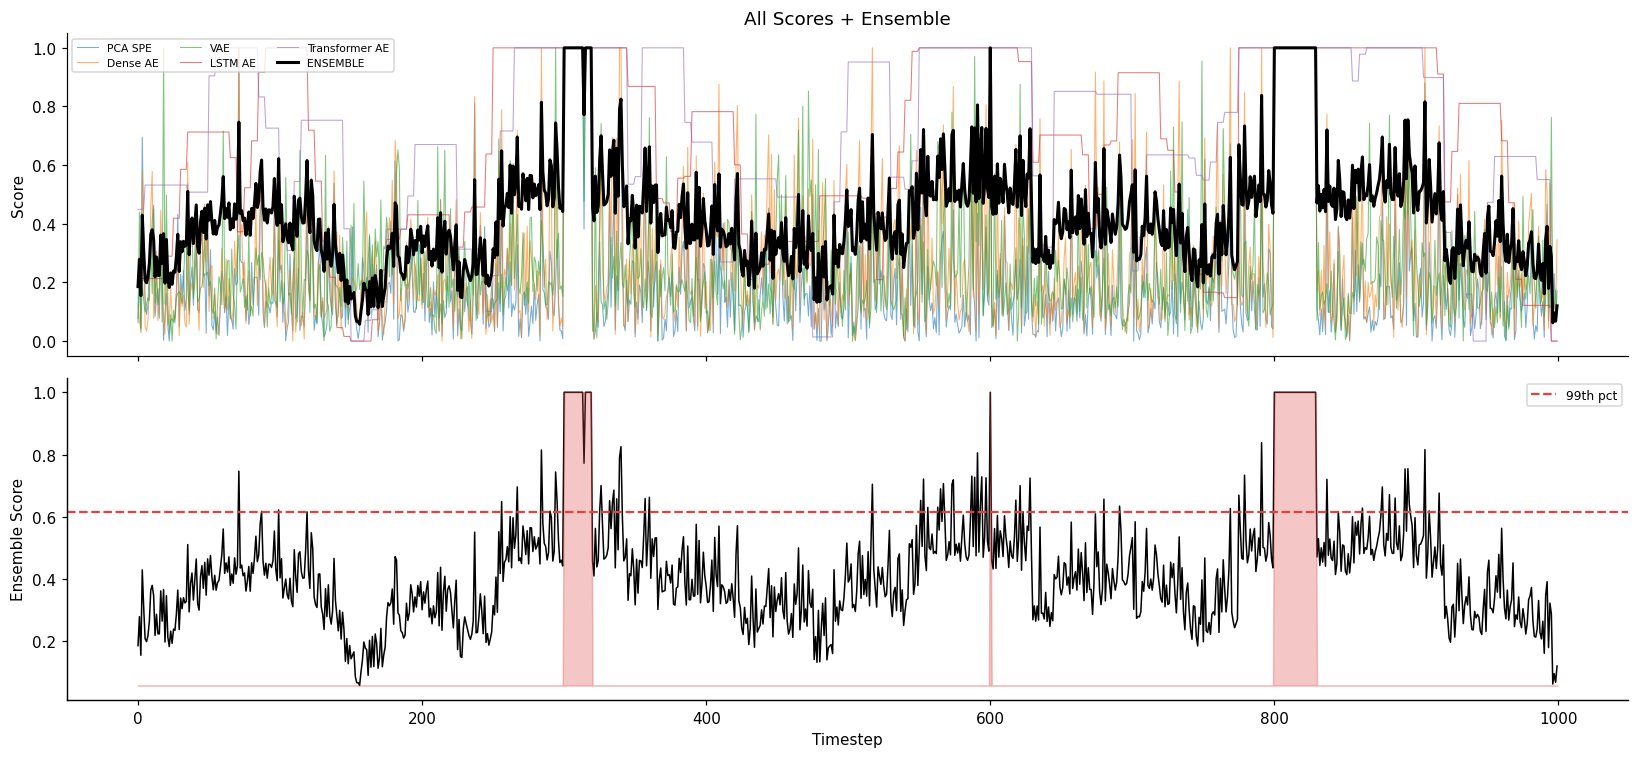

In [14]:
def norm01(s, n=train_sz):
    lo, hi = s[:n].min(), s[:n].max()
    return np.clip((s - lo) / (hi - lo + 1e-10), 0, 1)

score_dict = {
    "PCA SPE":        spe_scores,
    "Dense AE":       ae_scores,
    "VAE":            vae_scores,
    "LSTM AE":        ts_lstm,
    "Transformer AE": ts_trans,
}
normed = {k: norm01(v) for k, v in score_dict.items()}
ensemble = np.stack(list(normed.values())).mean(0)

print(f"{'Method':<20} {'AUROC':>8} {'AUPRC':>8}")
print("=" * 40)
from sklearn.metrics import average_precision_score
for name, sc in list(score_dict.items()) + [("ENSEMBLE", ensemble)]:
    auroc = roc_auc_score(y_mv, sc)
    auprc = average_precision_score(y_mv, sc)
    print(f"{name:<20} {auroc:>8.3f} {auprc:>8.3f}")

fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)
pal = plt.cm.tab10.colors
for i, (name, sc) in enumerate(normed.items()):
    axes[0].plot(sc, color=pal[i], lw=0.7, alpha=0.6, label=name)
axes[0].plot(ensemble, color="black", lw=2, label="ENSEMBLE")
axes[0].legend(fontsize=7, ncol=3); axes[0].set_ylabel("Score"); axes[0].set_title("All Scores + Ensemble")
axes[1].plot(ensemble, color="black", lw=1)
axes[1].axhline(np.percentile(ensemble[:train_sz], 99), color=COLORS["anomaly"], ls="--", label="99th pct")
ax2 = axes[1].twinx(); ax2.fill_between(range(len(y_mv)), y_mv, alpha=0.3, color=COLORS["anomaly"]); ax2.set_yticks([])
axes[1].set_xlabel("Timestep"); axes[1].set_ylabel("Ensemble Score"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

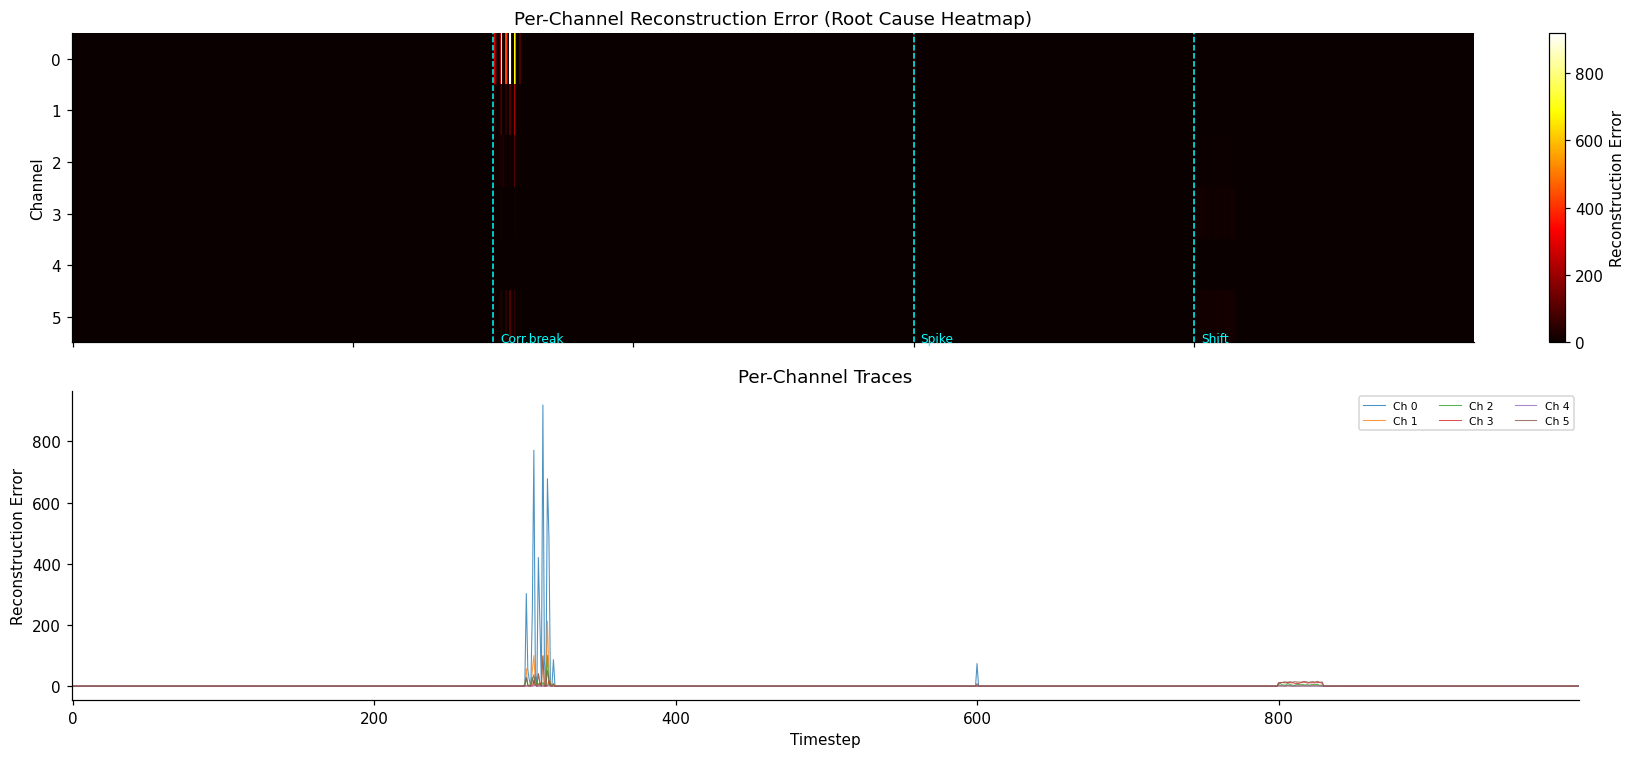

Root cause localisation: tells WHICH channel caused the anomaly


In [15]:
# Per-channel reconstruction error (root cause)
ae.eval()
with torch.no_grad():
    X_recon_ae = ae(X_all_t).numpy()
ch_err = (X_mv_sc - X_recon_ae) ** 2  # (n, 6)

fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)
im = axes[0].imshow(ch_err.T, aspect="auto", cmap="hot", interpolation="none")
plt.colorbar(im, ax=axes[0], fraction=0.02, label="Reconstruction Error")
axes[0].set_ylabel("Channel"); axes[0].set_title("Per-Channel Reconstruction Error (Root Cause Heatmap)")
for s, lbl in [(300, "Corr.break"), (600, "Spike"), (800, "Shift")]:
    axes[0].axvline(s, color="cyan", lw=1, ls="--")
    axes[0].text(s + 5, 5.5, lbl, fontsize=8, color="cyan")
for ch in range(6):
    axes[1].plot(ch_err[:, ch], lw=0.7, alpha=0.8, label=f"Ch {ch}")
axes[1].set_ylabel("Reconstruction Error"); axes[1].set_xlabel("Timestep")
axes[1].set_title("Per-Channel Traces"); axes[1].legend(fontsize=7, ncol=3)
plt.tight_layout(); plt.show()
print("Root cause localisation: tells WHICH channel caused the anomaly")

---
<a id='11'></a>
## Grand Summary

| Scenario | Recommended Method |
|---|---|
| 1D, Gaussian | Z-score, Grubbs |
| 1D, non-Gaussian | IQR, Modified Z-score, KDE |
| Multivariate, low-D | Mahalanobis / EllipticEnvelope |
| Multivariate, varying density | LOF |
| Large scale, high-D | Isolation Forest |
| Non-convex boundary | One-Class SVM |
| TS, linear | STL + IQR, ARIMA residuals |
| TS, patterns | Matrix Profile (STAMP/STOMP) |
| Streaming TS | **DAMP** |
| Multivariate TS, linear | PCA SPE + T² |
| Multivariate TS, deep | LSTM AE, Transformer AE, VAE |
| Production | **Ensemble** |

### Key principles
1. No universal detector — always evaluate on your data.
2. Use AUROC / AUPRC, not accuracy.
3. Semi-supervised beats unsupervised when clean normal data is available.
4. Preprocessing matters — STL, normalisation, windowing.
5. Ensembles are robust.
6. Per-channel scores enable root cause analysis.
7. For streaming → DAMP.

### Further reading
- Chandola et al., *Anomaly Detection: A Survey*, ACM CSUR 2009
- Yeh et al., *Matrix Profile I*, ICDM 2016
- Lu et al., *DAMP: A Dual-Stage Approximate Matrix Profile*, KDD 2022
- Xu et al., *Anomaly Transformer*, NeurIPS 2022
- PyOD library: https://pyod.readthedocs.io (40+ detectors)

---
## 🏋️ Exercises

**Exercise 1 (Short):** Apply STL decomposition to `ts`, combine the STL residual score with the Matrix Profile score (normalise and average). Does the ensemble outperform either alone? Measure AUROC.

**Exercise 2 (Medium):** Implement a sliding-window LOF detector for the univariate time series `ts`:
1. Create windows of size $w=50$, step $=10$
2. Extract features per window: `[mean, std, max−min, skewness]`
3. Apply LOF to the feature vectors
4. Map back to timestep scores and measure AUROC

**Exercise 3 (Hard — take-home):** Implement **USAD** (Audibert et al., KDD 2020):

Two autoencoders $AE_1$, $AE_2$:
- Phase 1: both reconstruct input (standard AE loss)
- Phase 2: $AE_1$ tries to fool $AE_2$; $AE_2$ tries to detect

Anomaly score: $\alpha\|x - AE_1(x)\|^2 + (1-\alpha)\|x - AE_2(AE_1(x))\|^2$

Compare to Dense AE on the multivariate dataset.

**Bonus:** Install PyOD and run 10+ detectors in 20 lines:
```python
from pyod.models.iforest import IForest
from pyod.models.lof import LOF
from pyod.models.auto_encoder import AutoEncoder
# etc.
```